# Chương 1: Xử Lý Dữ Liệu - Titanic và Breast Cancer

## Mục tiêu
Chứng minh ảnh hưởng của tiền xử lý đến hiệu suất mô hình với 2 datasets đơn giản: Titanic và Breast Cancer.

## Datasets
1. Titanic (Tabular): Missing values & Encoding
2. Breast Cancer (Numerical): Outliers & Scaling

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Dataset 1: Titanic (Tabular Data)

### Load và Explore Data

In [2]:
# Load Titanic Dataset
titanic = sns.load_dataset('titanic')
print("Titanic Dataset Shape:", titanic.shape)
print("\nFirst 5 rows:")
titanic.head()

Titanic Dataset Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


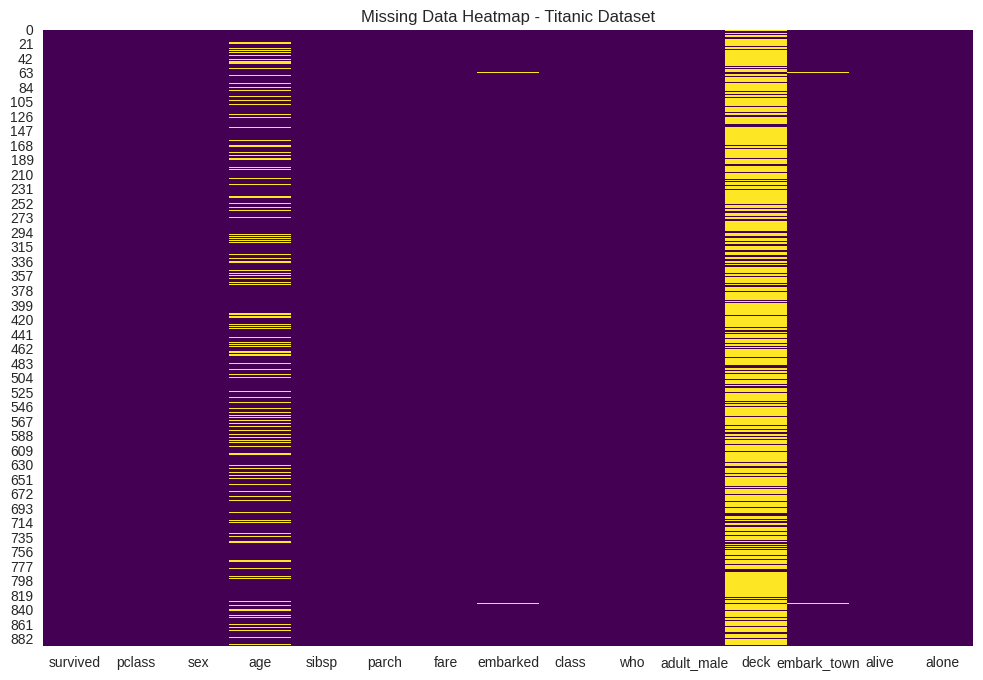

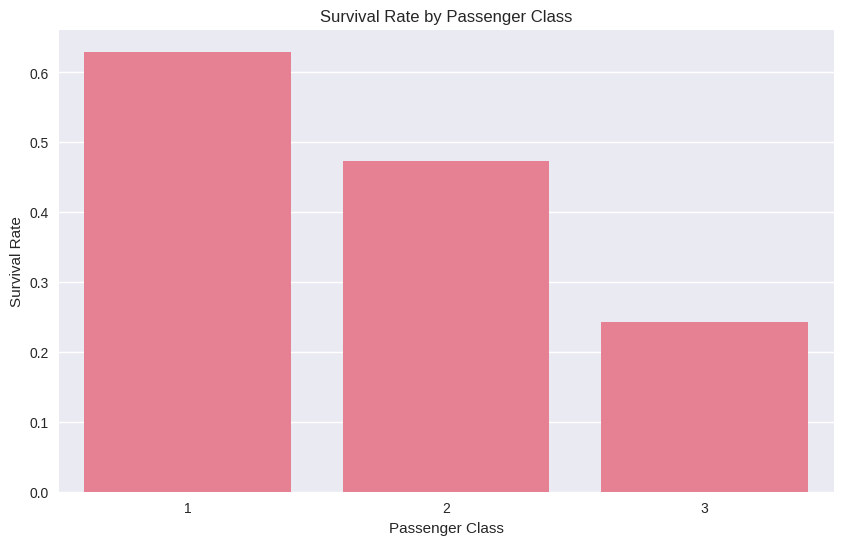

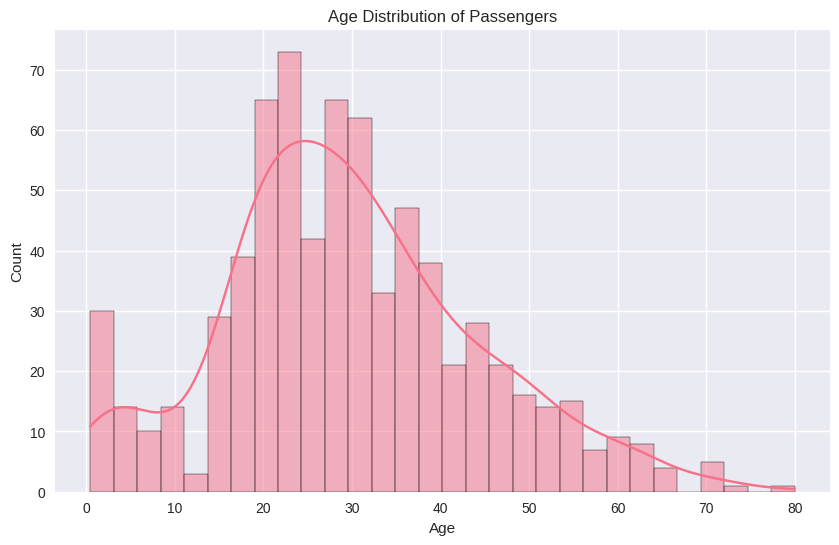

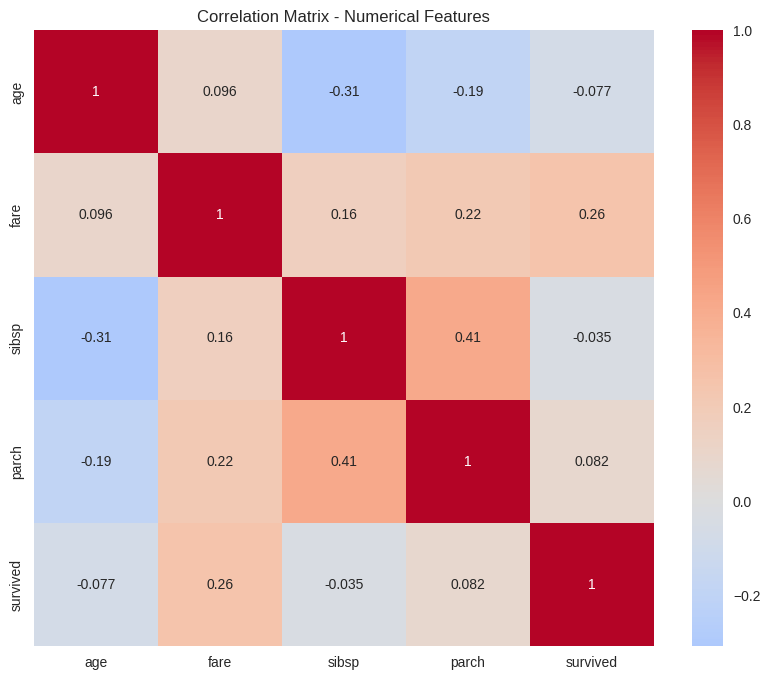

In [3]:
# Plot 1: Missing Data Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap - Titanic Dataset')
plt.savefig('titanic_missing_data_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Survival Rate by Class
plt.figure(figsize=(10, 6))
sns.barplot(x='pclass', y='survived', data=titanic, ci=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.savefig('titanic_survival_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(titanic['age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('titanic_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Correlation Heatmap (Numerical Features)
numerical_cols = ['age', 'fare', 'sibsp', 'parch', 'survived']
plt.figure(figsize=(10, 8))
correlation_matrix = titanic[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features')
plt.savefig('titanic_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Preprocessing Titanic Data

In [4]:
# Preprocessing Titanic Data
# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Create copy for preprocessing
titanic_processed = titanic[features + [target]].copy()

# Handle missing values
imputer = SimpleImputer(strategy='median')
titanic_processed['age'] = imputer.fit_transform(titanic_processed[['age']])
titanic_processed['fare'] = imputer.fit_transform(titanic_processed[['fare']])

# Fill embarked with mode
titanic_processed['embarked'] = titanic_processed['embarked'].fillna(titanic_processed['embarked'].mode()[0])

# Encode categorical variables
titanic_processed['sex'] = titanic_processed['sex'].map({'male': 0, 'female': 1})
titanic_processed['embarked'] = titanic_processed['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("After preprocessing:")
print(titanic_processed.isnull().sum())
titanic_processed.head()

After preprocessing:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,0,22.0,1,0,7.2500,0,0
1,1,1,38.0,1,0,71.2833,1,1
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,1
4,3,0,35.0,0,0,8.0500,0,0


### Model Comparison: Raw vs Preprocessed Data

In [5]:
# Model Comparison for Titanic
# Prepare raw data (with missing values)
titanic_raw = titanic[features + [target]].copy()
titanic_raw = titanic_raw.dropna()  # Drop rows with missing values
titanic_raw['sex'] = titanic_raw['sex'].map({'male': 0, 'female': 1})
titanic_raw['embarked'] = titanic_raw['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Split data
X_raw = titanic_raw[features]
y_raw = titanic_raw[target]
X_processed = titanic_processed[features]
y_processed = titanic_processed[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
X_train_proc, X_test_proc, y_train_proc, y_test_proc = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

# Train models
model = RandomForestClassifier(random_state=42)

# Raw data
model.fit(X_train_raw, y_train_raw)
y_pred_raw = model.predict(X_test_raw)
acc_raw = accuracy_score(y_test_raw, y_pred_raw)
f1_raw = f1_score(y_test_raw, y_pred_raw)

# Processed data
model.fit(X_train_proc, y_train_proc)
y_pred_proc = model.predict(X_test_proc)
acc_proc = accuracy_score(y_test_proc, y_pred_proc)
f1_proc = f1_score(y_test_proc, y_pred_proc)

print("Titanic Dataset Results:")
print(f"Raw Data - Accuracy: {acc_raw:.4f}, F1-Score: {f1_raw:.4f}")
print(f"Processed Data - Accuracy: {acc_proc:.4f}, F1-Score: {f1_proc:.4f}")
print(f"Improvement - Accuracy: {acc_proc - acc_raw:.4f}, F1-Score: {f1_proc - f1_raw:.4f}")

Titanic Dataset Results:
Raw Data - Accuracy: 0.7832, F1-Score: 0.7480
Processed Data - Accuracy: 0.8268, F1-Score: 0.7832
Improvement - Accuracy: 0.0436, F1-Score: 0.0352


## Dataset 2: Breast Cancer (Numerical Data)

### Load và Explore Data

In [6]:
# Load Breast Cancer Dataset
breast_cancer = load_breast_cancer()
X_bc = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_bc = pd.Series(breast_cancer.target, name='target')

print("Breast Cancer Dataset Shape:", X_bc.shape)
print("Features:", list(X_bc.columns[:5]), "...")
print("Target distribution:")
print(y_bc.value_counts())
X_bc.head()

Breast Cancer Dataset Shape: (569, 30)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...
Target distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


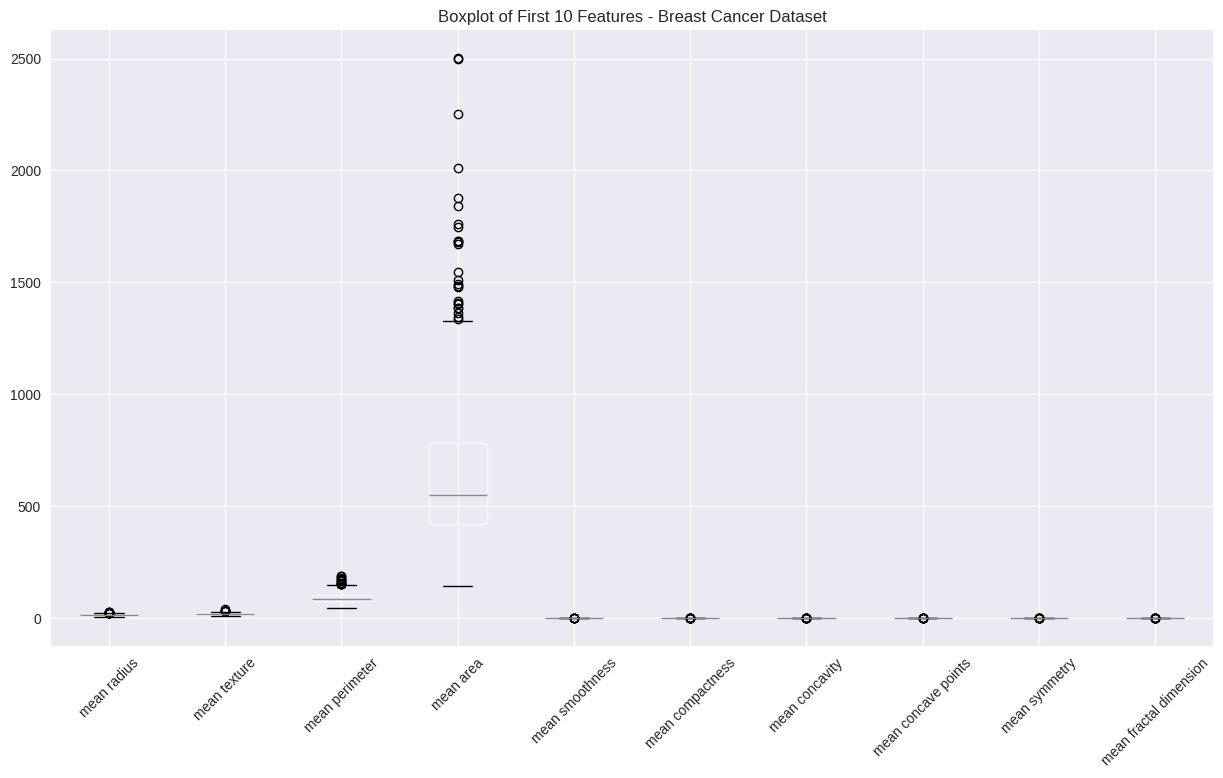

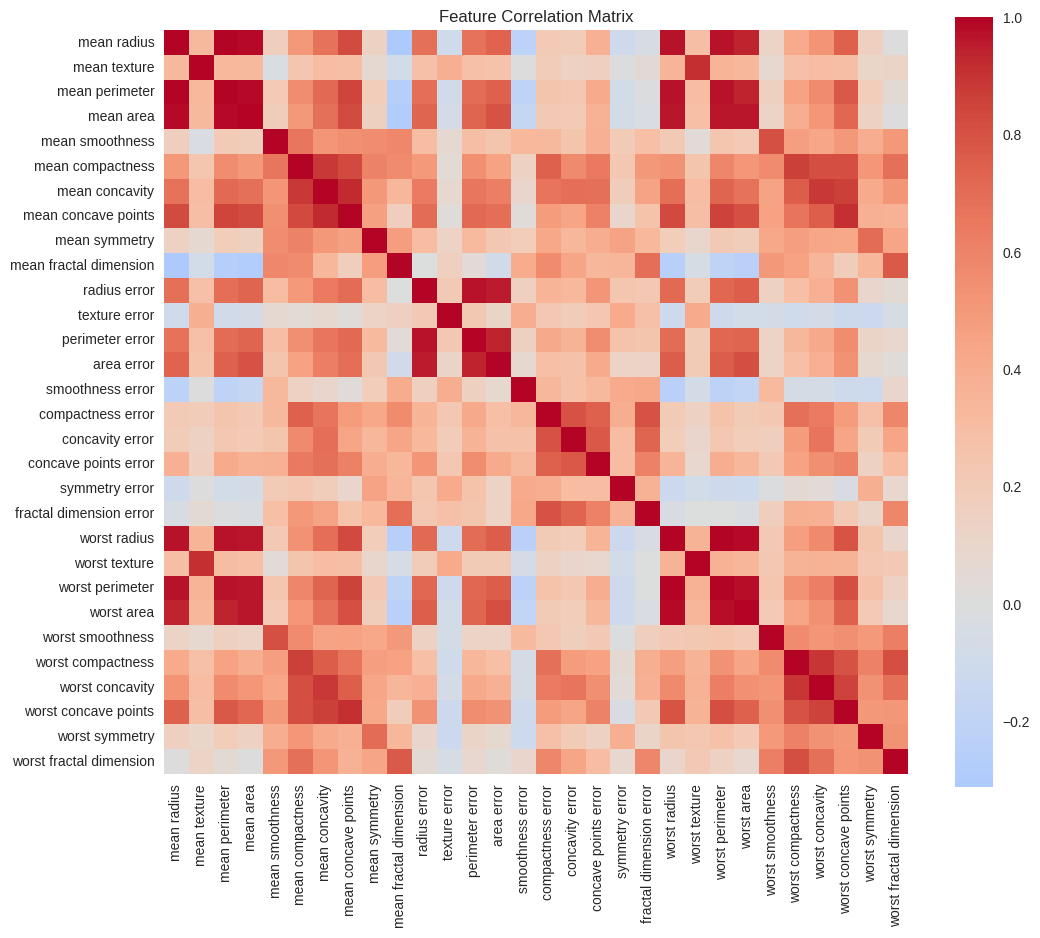

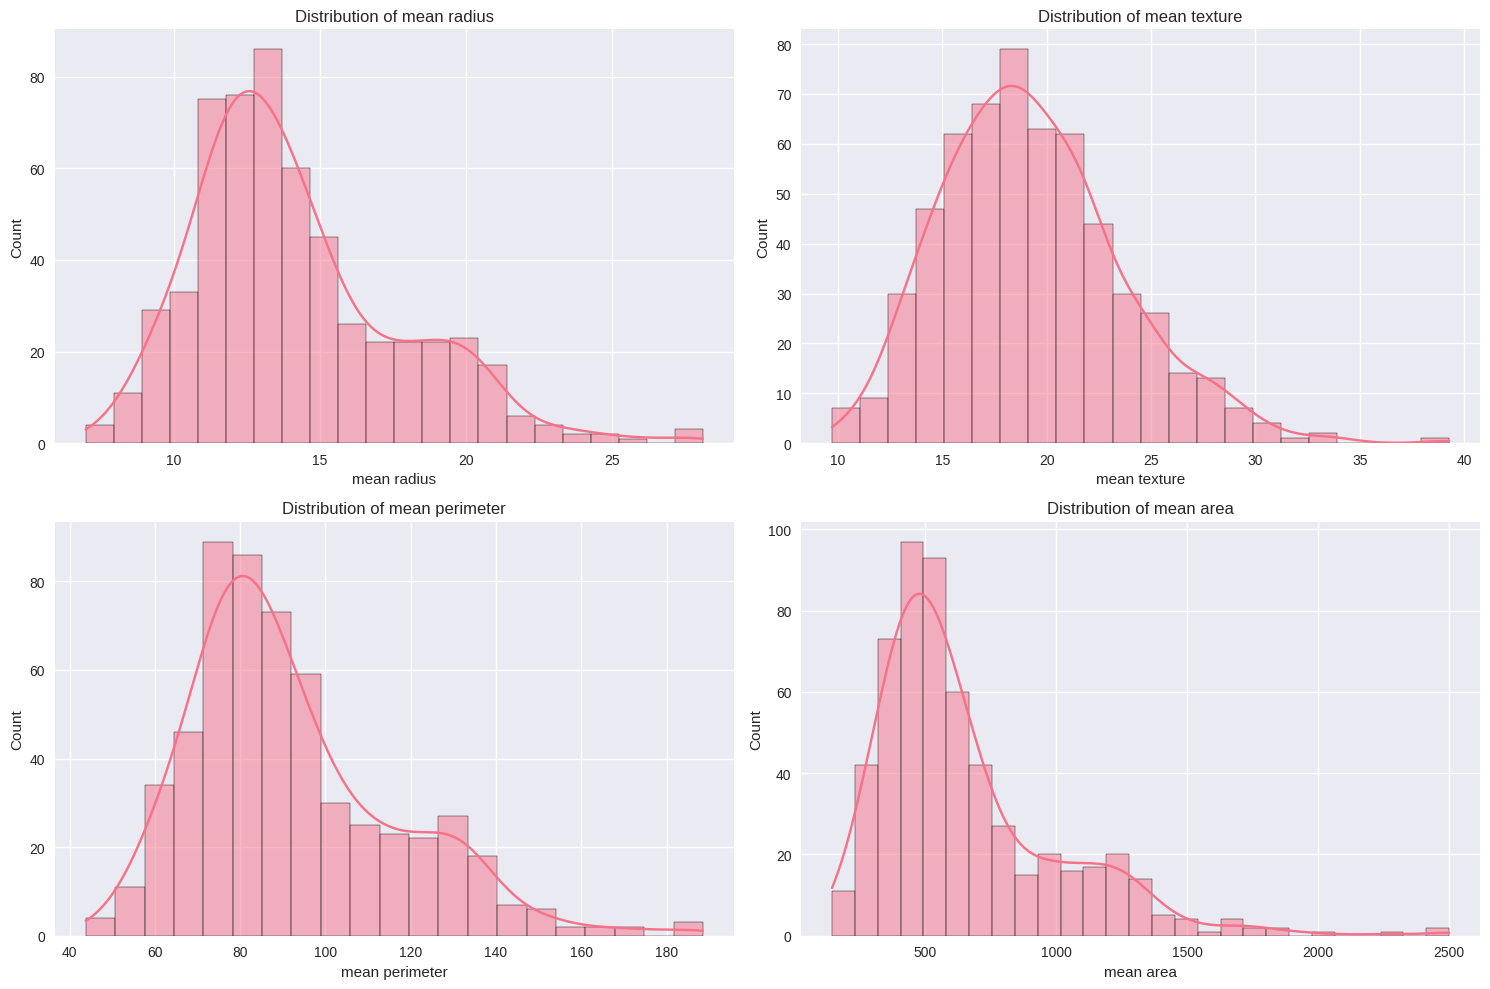

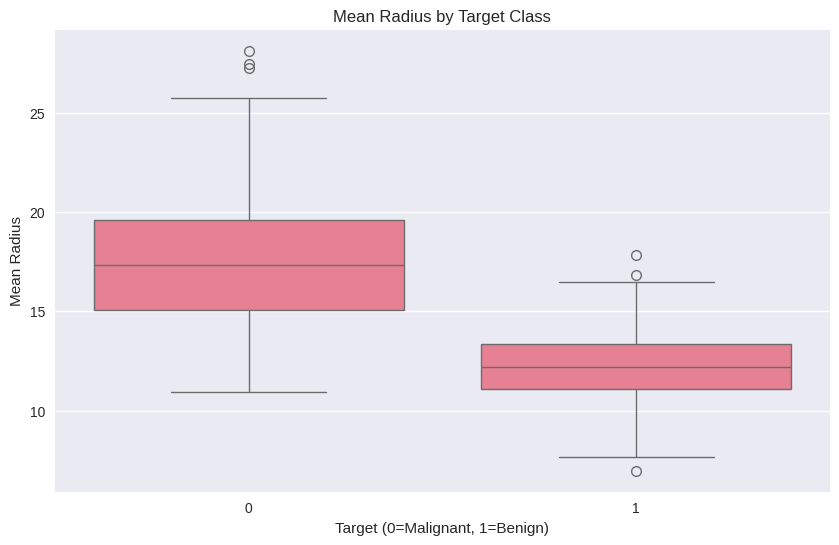

In [7]:
# Plot 1: Boxplot for Outlier Detection (first 10 features)
plt.figure(figsize=(15, 8))
X_bc.iloc[:, :10].boxplot()
plt.title('Boxplot of First 10 Features - Breast Cancer Dataset')
plt.xticks(rotation=45)
plt.savefig('breast_cancer_boxplot_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = X_bc.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.savefig('breast_cancer_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Feature Distribution Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    sns.histplot(X_bc[feature], ax=ax, kde=True)
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.savefig('breast_cancer_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Target vs Mean Radius
plt.figure(figsize=(10, 6))
sns.boxplot(x=y_bc, y=X_bc['mean radius'])
plt.title('Mean Radius by Target Class')
plt.xlabel('Target (0=Malignant, 1=Benign)')
plt.ylabel('Mean Radius')
plt.savefig('breast_cancer_target_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

### Preprocessing Breast Cancer Data

In [8]:
# Preprocessing Breast Cancer Data
# Standard Scaler
scaler_standard = StandardScaler()
X_bc_standard = pd.DataFrame(scaler_standard.fit_transform(X_bc), columns=X_bc.columns)

# Robust Scaler (handles outliers better)
scaler_robust = RobustScaler()
X_bc_robust = pd.DataFrame(scaler_robust.fit_transform(X_bc), columns=X_bc.columns)

print("Original data statistics:")
print(X_bc.describe().loc[['mean', 'std']].round(2))
print("\nStandard Scaled data statistics:")
print(X_bc_standard.describe().loc[['mean', 'std']].round(2))
print("\nRobust Scaled data statistics:")
print(X_bc_robust.describe().loc[['mean', 'std']].round(2))

Original data statistics:
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean        14.13         19.29           91.97     654.89             0.10   
std          3.52          4.30           24.30     351.91             0.01   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean              0.10            0.09                 0.05           0.18   
std               0.05            0.08                 0.04           0.03   

      mean fractal dimension  ...  worst radius  worst texture  \
mean                    0.06  ...         16.27          25.68   
std                     0.01  ...          4.83           6.15   

      worst perimeter  worst area  worst smoothness  worst compactness  \
mean           107.26      880.58              0.13               0.25   
std             33.60      569.36              0.02               0.16   

      worst concavity  worst concave points  worst symmetry  \
mean            

### Model Comparison: Different Scaling Methods

In [9]:
# Model Comparison for Breast Cancer
# Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)
X_train_std, X_test_std, _, _ = train_test_split(X_bc_standard, y_bc, test_size=0.2, random_state=42)
X_train_rob, X_test_rob, _, _ = train_test_split(X_bc_robust, y_bc, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)

# Raw data
model.fit(X_train_raw, y_train)
y_pred_raw = model.predict(X_test_raw)
acc_raw = accuracy_score(y_test, y_pred_raw)
f1_raw = f1_score(y_test, y_pred_raw)

# Standard Scaled
model.fit(X_train_std, y_train)
y_pred_std = model.predict(X_test_std)
acc_std = accuracy_score(y_test, y_pred_std)
f1_std = f1_score(y_test, y_pred_std)

# Robust Scaled
model.fit(X_train_rob, y_train)
y_pred_rob = model.predict(X_test_rob)
acc_rob = accuracy_score(y_test, y_pred_rob)
f1_rob = f1_score(y_test, y_pred_rob)

print("Breast Cancer Dataset Results:")
print(f"Raw Data - Accuracy: {acc_raw:.4f}, F1-Score: {f1_raw:.4f}")
print(f"Standard Scaled - Accuracy: {acc_std:.4f}, F1-Score: {f1_std:.4f}")
print(f"Robust Scaled - Accuracy: {acc_rob:.4f}, F1-Score: {f1_rob:.4f}")

Breast Cancer Dataset Results:
Raw Data - Accuracy: 0.9649, F1-Score: 0.9722
Standard Scaled - Accuracy: 0.9649, F1-Score: 0.9722
Robust Scaled - Accuracy: 0.9649, F1-Score: 0.9722


In [10]:
# Create directory for saved plots
import os
if not os.path.exists('plots'):
    os.makedirs('plots')

# Move all saved PNG files to plots directory
import shutil
png_files = [f for f in os.listdir('.') if f.endswith('.png')]
for file in png_files:
    shutil.move(file, os.path.join('plots', file))

print("All plots saved to 'plots' directory for report writing.")

All plots saved to 'plots' directory for report writing.
